# Lab — From Word2Vec to Road2Vec
### AI Mobility Technologies · Graduate Lab Notebook

In this lab you will:

1. Build intuition for **embeddings** — dense, learned vector representations — using **Word2Vec** on natural language.
2. Apply the *exact same machinery* to a real road network around USF/Tampa to produce **Road2Vec** embeddings.
3. Inspect what those embeddings learned: similar segments, clusters, and how they line up with the functional classification you already know from traffic engineering.

**The conceptual bet of this lab:** the meaning of a road segment can be learned from the *company it keeps* — the segments that frequently appear before and after it in trips. This is the same bet Word2Vec makes about words.


## 0. Setup

Run the install cell once. If you're on Colab, this is fast; on your laptop, give it ~1 min.


In [ ]:
# Run once. On Colab this is fast.
%pip install --quiet gensim osmnx scikit-learn matplotlib networkx plotly "nbformat>=4.2.0"

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gensim.downloader as api
from gensim.models import Word2Vec

import osmnx as ox
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

random.seed(42)
np.random.seed(42)

print("OSMnx:", ox.__version__)


OSMnx: 2.1.0


## 1. Why embeddings? Why not one-hot?

You already encode things as vectors all the time:

- A traffic state at a detector: `[flow, speed, density/occupancy]`
- A traffic state of a long segment as a vector of density values of road cells like CA or CTM we introduced in traffic flow theory class
- A row of an OD matrix
- A crash record's feature vector for an SPF

So "describe an object with numbers" is not new. The question is:

> *What if we **learned** those numbers from data instead of hand-engineering them?*

Before answering that, let's see why the obvious encoding — **one-hot** — fails.


In [20]:
# Suppose we have 5 intersections and we one-hot encode their IDs.
intersections = ["int_A", "int_B", "int_C", "int_D", "int_E"]
n = len(intersections)
one_hot = np.eye(n)
df = pd.DataFrame(one_hot, index=intersections, columns=intersections)
print("One-hot vectors:")
print(df)

# Pairwise Euclidean distances
from scipy.spatial.distance import pdist, squareform
dist = squareform(pdist(one_hot, metric="euclidean"))
print("\nPairwise distances:")
print(pd.DataFrame(dist, index=intersections, columns=intersections))


One-hot vectors:
       int_A  int_B  int_C  int_D  int_E
int_A    1.0    0.0    0.0    0.0    0.0
int_B    0.0    1.0    0.0    0.0    0.0
int_C    0.0    0.0    1.0    0.0    0.0
int_D    0.0    0.0    0.0    1.0    0.0
int_E    0.0    0.0    0.0    0.0    1.0

Pairwise distances:
          int_A     int_B     int_C     int_D     int_E
int_A  0.000000  1.414214  1.414214  1.414214  1.414214
int_B  1.414214  0.000000  1.414214  1.414214  1.414214
int_C  1.414214  1.414214  0.000000  1.414214  1.414214
int_D  1.414214  1.414214  1.414214  0.000000  1.414214
int_E  1.414214  1.414214  1.414214  1.414214  0.000000


Notice: **every pair of distinct intersections is exactly the same distance apart** (`sqrt(2)`).

The encoding has *no idea* that two diamond interchanges are more alike than a diamond and a rural T-intersection. And if you scale this up to 50,000 intersections, you get 50,000-D sparse vectors that no model can generalize across.

This is the same reason you don't one-hot encode crash types in advanced safety models — categorical IDs throw away similarity structure.

**The fix:** replace the one-hot vector with a short, dense vector whose *geometry* encodes **similarity**. Those are embeddings.


## 2. Word2Vec — the canonical example

We'll start by *using* pre-trained word embeddings (GloVe, 50-dim, trained on Wikipedia + Gigaword) before we train one ourselves. This lets you see the *result* of a successful embedding before worrying about how it was built.

> Loading takes ~30 sec the first time and is cached afterward.


In [4]:
glove = api.load("glove-wiki-gigaword-50")   # 400k words × 50 dimensions
print("Vocabulary size:", len(glove.key_to_index))
print("Vector dimension:", glove.vector_size)
print("\nA word is just a 50-dim vector. Here is 'traffic':")
print(glove["traffic"])


[==================================================] 100.0% 66.0/66.0MB downloaded
Vocabulary size: 400000
Vector dimension: 50

A word is just a 50-dim vector. Here is 'traffic':
[ 0.36401  -0.059493  0.57209  -0.15496  -1.2187   -0.34592  -0.26094
  0.044862  1.149    -0.7007    0.085758 -0.3567   -0.67887  -0.16594
  0.23384  -0.18573  -0.58934   0.17998  -0.32786  -1.0948    0.93362
 -0.51249  -0.68087   0.91908   0.49608  -1.3029    0.6253    0.70093
  1.3782    0.1645    3.1035    0.66612   0.6738   -0.9878   -0.32676
  0.1538    0.39712  -0.6129   -0.36269   1.6848   -0.43083   0.5326
  0.65015  -0.13254  -0.6359   -0.54063   0.20286  -0.45146   0.91323
 -0.018022]


### 2.1 Similarity — words with similar meaning are close

`gensim` returns the words whose embedding vectors have the highest cosine similarity to a query.


In [5]:
for q in ["traffic", "vehicle", "intersection", "highway", "pedestrian"]:
    print(f"\nMost similar to '{q}':")
    for word, score in glove.most_similar(q, topn=5):
        print(f"   {word:15s} {score:.3f}")



Most similar to 'traffic':
   rail            0.778
   train           0.767
   congestion      0.762
   transit         0.761
   highways        0.761

Most similar to 'vehicle':
   vehicles        0.896
   car             0.883
   truck           0.865
   cars            0.809
   passenger       0.799

Most similar to 'intersection':
   intersects      0.850
   terminus        0.828
   junction        0.804
   highway         0.804
   intersecting    0.795

Most similar to 'highway':
   route           0.868
   interstate      0.855
   highways        0.848
   freeway         0.842
   terminus        0.828

Most similar to 'pedestrian':
   walkway         0.797
   lanes           0.782
   thoroughfare    0.775
   pedestrians     0.749
   underpass       0.745


Notice that "intersection" returns *intersections, junction, crossing, intersecting* — words that share semantic context. The model was never told these were related; it learned that purely from co-occurrence in Wikipedia text.

### 2.2 Analogies — the famous trick

Word2Vec embeddings support vector arithmetic. The textbook example:

`king − man + woman ≈ queen`

The reason this works: directions in the embedding space correspond to consistent *relationships* (gender, capital-of, plural-of, …).


In [6]:
def analogy(a, b, c, topn=3):
    # a is to b as c is to ?
    print(f"{a} : {b}  ::  {c} : ?")
    for word, score in glove.most_similar(positive=[b, c], negative=[a], topn=topn):
        print(f"   {word:15s} {score:.3f}")
    print()

analogy("man", "king", "woman")
analogy("paris", "france", "germany")
analogy("car", "road", "train")     # transportation-ish
analogy("walking", "pedestrian", "driving")


man : king  ::  woman : ?
   queen           0.852
   throne          0.766
   prince          0.759

paris : france  ::  germany : ?
   denmark         0.803
   poland          0.762
   slovakia        0.754

car : road  ::  train : ?
   route           0.816
   bridge          0.790
   east            0.769

walking : pedestrian  ::  driving : ?
   vehicular       0.755
   speeding        0.744
   traffic         0.712



Some analogies will be cleaner than others. The lesson is not that every analogy works — it's that the embedding *space has structure*, and that structure was learned, not designed.

### 2.3 Visualizing embeddings — PCA to 2D

Pick a curated set of transport-related words and project their 50-D embeddings into 2D. Cohesive groups should cluster.


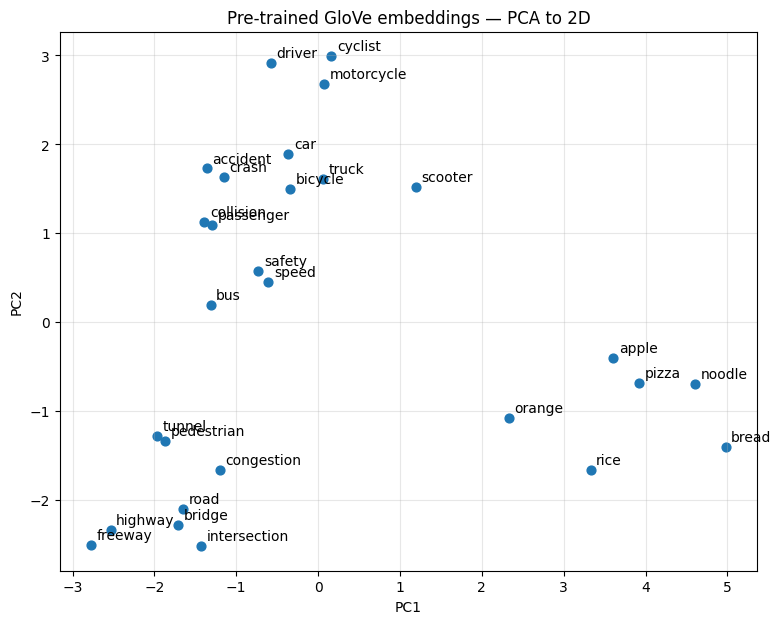

In [7]:
words = [
    # vehicles
    "car", "truck", "bus", "bicycle", "motorcycle", "scooter",
    # infrastructure
    "highway", "road", "freeway", "intersection", "bridge", "tunnel",
    # users
    "driver", "pedestrian", "passenger", "cyclist",
    # safety / operations
    "crash", "accident", "collision", "safety", "speed", "congestion",
    # contrast group (food)
    "pizza", "bread", "apple", "orange", "rice", "noodle",
]
vecs = np.array([glove[w] for w in words])

pca = PCA(n_components=2)
xy = pca.fit_transform(vecs)

plt.figure(figsize=(9, 7))
plt.scatter(xy[:, 0], xy[:, 1], s=40)
for (x, y), w in zip(xy, words):
    plt.annotate(w, (x, y), xytext=(4, 4), textcoords="offset points")
plt.title("Pre-trained GloVe embeddings — PCA to 2D")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(alpha=0.3)
plt.show()


### 2.3.1 Interactive 3D — seeing geometric closeness in high dimensions

The static 2D plot above is a *projection* of 50-dimensional vectors onto two axes — about 40% of the variance shows up, the other 60% is squashed away. So when two words look close in 2D you can't tell whether they're really close in 50D or just collapsed onto the same spot by accident.

Two practical tricks help students see geometric closeness in a high-dimensional space:

1. **Use one more dimension.** A 3D PCA recovers another ~10% of the variance and, more importantly, lets the eye separate clusters that were stacked in 2D. Rotating the figure does most of the work — the brain is good at parsing 3D structure from motion.
2. **Anchor the truth.** Compute the *cosine similarity in the original 50D space* between a focal word ("traffic") and its top-5 neighbors, then **draw lines** from "traffic" to those neighbors in the 3D projection. The lines are short whenever 3D preserves the 50D closeness, and long whenever the projection has lied. That's the visual proof that "traffic" and "road"/"highway"/"transit" really are nearby in the embedding's native geometry, not just in our cherry-picked 2D view.

Drag the figure below to rotate; hover any dot to see the word and its category; the gold lines connect "traffic" to its nearest neighbors in the full 50-D cosine space.


In [ ]:
import plotly.graph_objects as go

# ----------------------------------------------------------
# Words grouped by semantic category. The model was never told
# these groupings — that's the whole point.
# ----------------------------------------------------------
word_categories = {
    "vehicles":         ["car", "truck", "bus", "bicycle", "motorcycle", "scooter", "taxi", "van"],
    "infrastructure":   ["highway", "road", "freeway", "intersection", "bridge",
                         "tunnel", "lane", "ramp", "interchange"],
    "road_users":       ["driver", "pedestrian", "passenger", "cyclist", "commuter"],
    "safety_ops":       ["crash", "accident", "collision", "safety", "speed",
                         "congestion", "signal", "speeding"],
    "food_contrast":    ["pizza", "bread", "apple", "orange", "rice", "burger", "salad"],
    "animals_contrast": ["dog", "cat", "bird", "horse", "fish"],
}

words, cats = [], []
for cat, ws in word_categories.items():
    for w in ws:
        if w in glove.key_to_index:
            words.append(w)
            cats.append(cat)

X = np.array([glove[w] for w in words])

# ----------------------------------------------------------
# 1) Numerical truth (independent of any 2D/3D projection):
#    cosine similarities to a focal word in the full 50-D space.
# ----------------------------------------------------------
focal = "traffic"
probe = ["road", "highway", "intersection", "bus", "pedestrian",
         "pizza", "dog", "salad"]
print(f"Cosine similarity to '{focal}' in the original 50-D GloVe space:")
print(f"   {'word':<14s} cosine")
print(f"   {'-'*14} -------")
for w in probe:
    if w in glove.key_to_index:
        print(f"   {w:<14s} {glove.similarity(focal, w): .3f}")
print("\nNote: transportation words sit around 0.5–0.8; the food / animal contrast")
print("words drop near 0.1. That's the geometric closeness we're about to see.\n")

# ----------------------------------------------------------
# 2) Project the 50-D vectors to 3-D with PCA.
# ----------------------------------------------------------
pca3 = PCA(n_components=3, random_state=42)
xyz = pca3.fit_transform(X)
ev = pca3.explained_variance_ratio_
print(f"3-D PCA explains {ev.sum()*100:.0f}% of variance "
      f"(PC1 {ev[0]*100:.0f}%, PC2 {ev[1]*100:.0f}%, PC3 {ev[2]*100:.0f}%).")

# Top-K cosine neighbors of the focal word, computed in the FULL 50-D space.
TOPK = 5
neighbors_50d = glove.most_similar(focal, topn=TOPK)
nb_words   = [w for w, _ in neighbors_50d]
nb_scores  = [s for _, s in neighbors_50d]
nb_xyz     = pca3.transform(np.array([glove[w] for w in nb_words]))
fxyz       = pca3.transform(glove[focal].reshape(1, -1))[0]

# ----------------------------------------------------------
# 3) Build the interactive figure.
# ----------------------------------------------------------
USF_GREEN = "#006747"
USF_GOLD  = "#CFC493"
CAT_COLOR = {
    "vehicles":         "#006747",  # USF green
    "infrastructure":   "#0E8A5F",
    "road_users":       "#3DA978",
    "safety_ops":       "#7BC8A0",
    "food_contrast":    "#C45A5A",
    "animals_contrast": "#8C6D9E",
}

fig = go.Figure()

# One trace per category — clean legend, hover shows word + category.
for cat in word_categories:
    mask = [c == cat for c in cats]
    if not any(mask):
        continue
    fig.add_trace(go.Scatter3d(
        x=xyz[mask, 0], y=xyz[mask, 1], z=xyz[mask, 2],
        mode="markers+text",
        marker=dict(size=6, color=CAT_COLOR[cat], opacity=0.85,
                    line=dict(width=0.5, color="white")),
        text=[w for w, m in zip(words, mask) if m],
        textposition="top center",
        textfont=dict(size=10, color="#222"),
        name=cat.replace("_", " "),
        hovertemplate=("<b>%{text}</b><br>category: " + cat
                       + "<br>PC1=%{x:.2f} PC2=%{y:.2f} PC3=%{z:.2f}<extra></extra>"),
    ))

# Lines from focal word to its top-K neighbors in 50-D cosine space.
line_x, line_y, line_z = [], [], []
for (x, y, z) in nb_xyz:
    line_x += [fxyz[0], x, None]
    line_y += [fxyz[1], y, None]
    line_z += [fxyz[2], z, None]
fig.add_trace(go.Scatter3d(
    x=line_x, y=line_y, z=line_z,
    mode="lines",
    line=dict(color=USF_GOLD, width=4),
    name=f"top-{TOPK} cosine neighbors of '{focal}' (in 50-D)",
    hoverinfo="skip",
))

# Highlight the focal word with a USF-gold diamond.
fig.add_trace(go.Scatter3d(
    x=[fxyz[0]], y=[fxyz[1]], z=[fxyz[2]],
    mode="markers+text",
    marker=dict(size=14, color=USF_GOLD, symbol="diamond",
                line=dict(width=2, color=USF_GREEN)),
    text=[f"<b>{focal}</b>"],
    textposition="top center",
    textfont=dict(size=14, color=USF_GREEN),
    name=f"focal: {focal}",
    hovertemplate=f"<b>{focal}</b> (focal word)<extra></extra>",
))

# Highlight the neighbors and label them with the cosine score (in 50-D).
fig.add_trace(go.Scatter3d(
    x=nb_xyz[:, 0], y=nb_xyz[:, 1], z=nb_xyz[:, 2],
    mode="markers+text",
    marker=dict(size=10, color=USF_GREEN, symbol="circle",
                line=dict(width=2, color=USF_GOLD)),
    text=[f"{w} (cos {s:.2f})" for w, s in neighbors_50d],
    textposition="bottom center",
    textfont=dict(size=11, color=USF_GREEN),
    name="neighbor + cosine to focal",
    hovertemplate=("<b>%{text}</b><br>"
                   "cosine measured in the original 50-D space<extra></extra>"),
))

fig.update_layout(
    title=dict(
        text=("Interactive 3-D PCA of GloVe embeddings — "
              "semantically similar words are geometrically close<br>"
              f"<sup>3D explains {ev.sum()*100:.0f}% of variance · "
              f"gold lines connect '{focal}' to its top-{TOPK} cosine neighbors in the full 50-D space · "
              "drag to rotate, hover for word</sup>"),
        x=0.5, xanchor="center"),
    scene=dict(
        xaxis_title="PC 1", yaxis_title="PC 2", zaxis_title="PC 3",
        bgcolor="white",
    ),
    legend=dict(orientation="v", x=1.02, y=0.5),
    margin=dict(l=0, r=0, t=90, b=0),
    width=1000, height=700,
)

fig.show()


You should see vehicles, infrastructure, users, and food forming distinct neighborhoods. *Nobody told the model what category each word belonged to.*

### 2.4 How is this learned? (1-minute version)

Word2Vec uses one of two objectives:

- **Skip-gram:** given a center word, predict the surrounding words.
- **CBOW:** given the surrounding words, predict the center word.

Either way, words that appear in **similar contexts** are pushed to have **similar vectors**. The geometry is a byproduct of contextual co-occurrence.

> Headline rule: *"You are who you hang out with."*

Let's actually train a tiny one to confirm the mechanism.


In [8]:
# A toy transportation corpus. With this little data the embeddings
# will be noisy, but the API is identical to what we'll use for road2vec.
toy_corpus = [
    "the car drove down the highway",
    "the truck rumbled along the freeway",
    "the bus stopped at the intersection",
    "the cyclist crossed the intersection",
    "the pedestrian walked across the crosswalk",
    "the driver checked the mirror before changing lanes",
    "congestion built up on the highway during rush hour",
    "the freeway was congested with trucks and cars",
    "the signal turned red and the car stopped",
    "the bicycle lane was painted next to the road",
    "the motorcycle accelerated past the truck",
    "the pedestrian waited for the walk signal",
    "the driver yielded to the cyclist at the intersection",
    "buses and cars share the arterial road",
    "the freeway connects the suburbs to downtown",
]
sentences = [s.lower().split() for s in toy_corpus]

mini = Word2Vec(
    sentences,
    vector_size=20,
    window=3,
    min_count=1,
    sg=1,            # skip-gram
    workers=1,
    epochs=400,
    seed=42,
)

print("Most similar to 'car' in the toy model:")
for w, s in mini.wv.most_similar("car", topn=5):
    print(f"   {w:15s} {s:.3f}")


Most similar to 'car' in the toy model:
   stopped         0.985
   turned          0.982
   signal          0.982
   crosswalk       0.981
   congestion      0.980


With 15 sentences the result is rough, but you can see the mechanism: words like *truck*, *bus*, *motorcycle* should rank near *car* because they share contexts.

In practice, real word2vec models are trained on **billions of tokens**. Road networks have far fewer "tokens" (intersections), but each gets visited many times across many trajectories — so the math still works.


## 3. From words to roads — the conceptual mapping

Here is the analogy that powers road2vec:

| Language (Word2Vec) | Road network (Road2Vec) |
|---|---|
| word | intersection (graph node) — or road segment (edge) |
| sentence | trajectory: sequence of intersections a vehicle passes through |
| corpus | collection of many trajectories |
| skip-gram window | spatially nearby intersections along a trip |
| analogy *king − man + woman ≈ queen* | *downtown_signalized − signal + stop ≈ downtown_unsignalized*  (sometimes!) |

The big insight: **if you have GPS trajectories, you have "sentences" of intersections.**

We don't have a public GPS dataset to hand out in lab, so we'll do the standard substitute used in the DeepWalk / node2vec line of work: **generate random walks on the road network graph and treat them as synthetic trajectories**. This is the same technique used in real road2vec / highway2vec papers when trajectory data is scarce.

> If you have access to real GPS data later in the course, you can drop it in where the random walks are.


## 4. Pull a real road network with OSMnx

We'll grab the drive-network within a 2 km radius of USF Tampa.


In [9]:
# A 2 km drive network around USF Tampa.
# This call hits OpenStreetMap; first run takes ~10-30 sec.
G = ox.graph_from_address(
    "University of South Florida, Tampa, FL",
    dist=2000,
    network_type="drive",
)
G = ox.convert.to_undirected(G)   # treat the graph as undirected for walks
print(f"Nodes (intersections): {G.number_of_nodes()}")
print(f"Edges (road segments): {G.number_of_edges()}")


Nodes (intersections): 495
Edges (road segments): 737


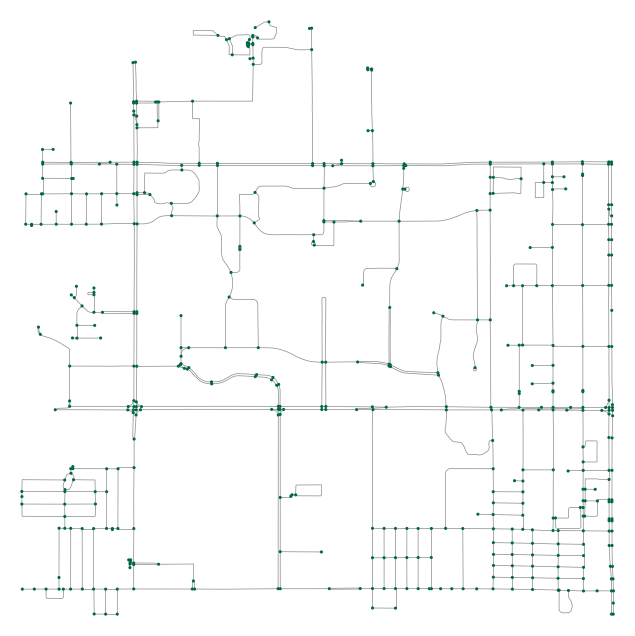

In [10]:
# Plot it
fig, ax = ox.plot_graph(G, node_size=5, edge_linewidth=0.5,
                       bgcolor="white", node_color="#006747",
                       edge_color="#888")


## 5. Random walks as synthetic trajectories

A random walk starts at some intersection and, at each step, picks a uniformly random neighbor. A sequence of, say, 20 such hops is a synthetic "trip" through the network.

We'll generate **N walks per starting node** so every intersection appears in many "sentences" — analogous to a word appearing in many contexts.


In [11]:
def random_walk(G, start, walk_length=20, rng=random):
    walk = [start]
    for _ in range(walk_length - 1):
        nbrs = list(G.neighbors(walk[-1]))
        if not nbrs:
            break
        walk.append(rng.choice(nbrs))
    return walk

WALKS_PER_NODE = 20
WALK_LENGTH    = 30

rng = random.Random(42)
walks = []
nodes = list(G.nodes())
for _ in range(WALKS_PER_NODE):
    rng.shuffle(nodes)
    for n in nodes:
        walks.append([str(x) for x in random_walk(G, n, WALK_LENGTH, rng)])

print(f"Generated {len(walks)} synthetic trajectories")
print("Example trajectory (first 10 nodes):")
print(walks[0][:10])


Generated 9900 synthetic trajectories
Example trajectory (first 10 nodes):
['97839327', '97839322', '97772012', '3627213200', '355782269', '355782270', '355782269', '355782270', '97781682', '355782270']


## 6. Train Road2Vec

Same Word2Vec API as before. The only difference: our "words" are intersection IDs.


In [12]:
EMB_DIM = 64

road2vec = Word2Vec(
    sentences=walks,
    vector_size=EMB_DIM,
    window=5,        # how many neighboring nodes count as "context"
    min_count=1,
    sg=1,            # skip-gram
    workers=1,
    epochs=10,
    seed=42,
)
print(f"Trained embeddings for {len(road2vec.wv)} intersections "
      f"in {EMB_DIM} dimensions.")


Trained embeddings for 495 intersections in 64 dimensions.


### 6.1 Find similar intersections

Pick any node. Ask the model for the 5 most similar nodes by cosine similarity in embedding space. Plot them on the map and see whether they cluster geographically and/or functionally.


In [13]:
# Pick a query node near the center of the network
center_node = ox.distance.nearest_nodes(
    G,
    X=ox.convert.graph_to_gdfs(G, edges=False).geometry.x.mean(),
    Y=ox.convert.graph_to_gdfs(G, edges=False).geometry.y.mean(),
)
similar = road2vec.wv.most_similar(str(center_node), topn=5)
print(f"Query intersection: {center_node}")
print("Most similar intersections in embedding space:")
for nid, score in similar:
    print(f"   node {nid}   cosine={score:.3f}")


Query intersection: 97882350
Most similar intersections in embedding space:
   node 97766865   cosine=0.913
   node 97802396   cosine=0.910
   node 560730311   cosine=0.909
   node 313805931   cosine=0.894
   node 561931174   cosine=0.857


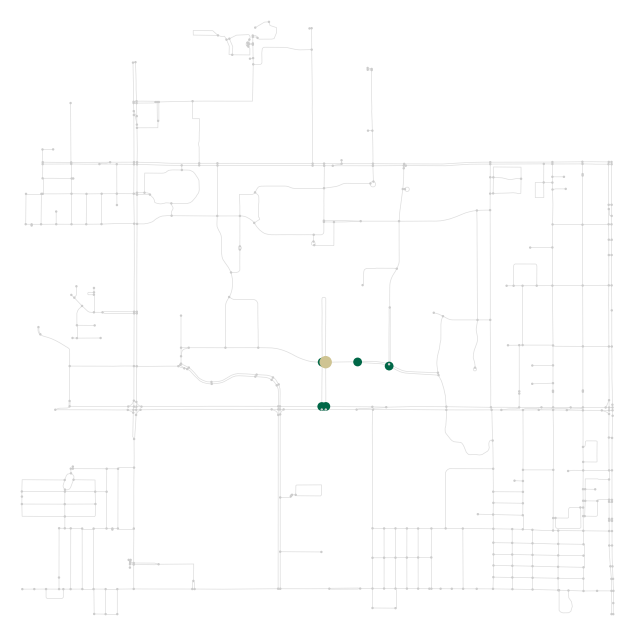

In [14]:
# Plot the query node + its top-5 nearest in embedding space
similar_ids = [int(nid) for nid, _ in similar]
node_colors = []
node_sizes  = []
for n in G.nodes():
    if n == center_node:
        node_colors.append("#CFC493")   # USF gold for the query
        node_sizes.append(80)
    elif n in similar_ids:
        node_colors.append("#006747")   # USF green for the matches
        node_sizes.append(40)
    else:
        node_colors.append("#cccccc")
        node_sizes.append(3)

fig, ax = ox.plot_graph(
    G,
    node_color=node_colors, node_size=node_sizes,
    edge_color="#dddddd", edge_linewidth=0.5,
    bgcolor="white",
)


### 6.2 Visualize the embedding space colored by road class

For each intersection, we compute the **dominant highway type** of its incident edges (residential, primary, motorway, …) — the OSM equivalent of functional classification — and color the embedding scatterplot by it.

If road2vec has learned anything useful, intersections of similar functional class should cluster *even though we never gave the model the highway type*.


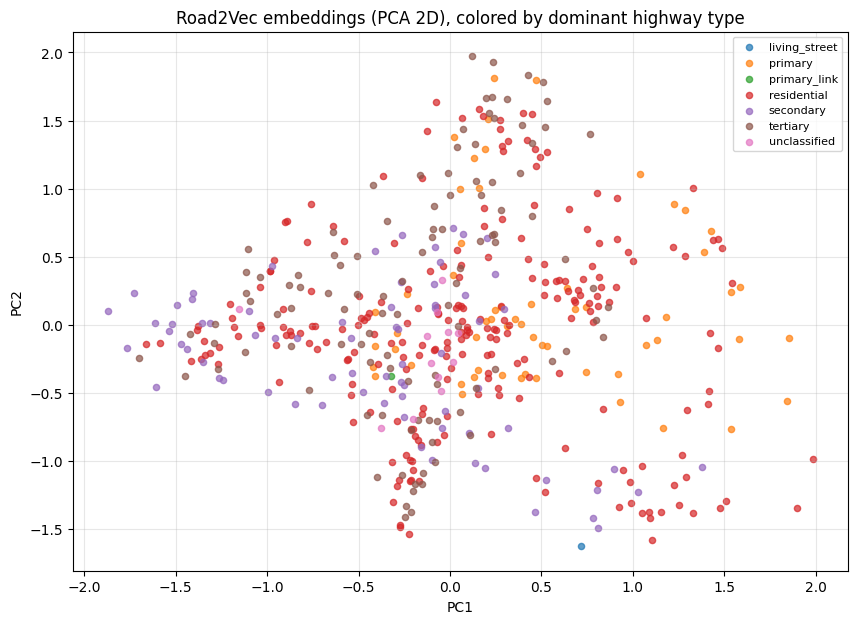

In [15]:
# Build a dominant-highway-type label per node
def edge_hwy(data):
    h = data.get("highway")
    if isinstance(h, list):
        return h[0]
    return h

from collections import Counter
node_hwy = {}
for n in G.nodes():
    types = []
    for _, _, data in G.edges(n, data=True):
        t = edge_hwy(data)
        if t:
            types.append(t)
    node_hwy[n] = Counter(types).most_common(1)[0][0] if types else "unknown"

# Project embeddings to 2D
node_ids   = [int(nid) for nid in road2vec.wv.index_to_key]
emb_matrix = np.array([road2vec.wv[str(nid)] for nid in node_ids])

pca2 = PCA(n_components=2).fit_transform(emb_matrix)

# Plot, colored by road type
labels = [node_hwy.get(nid, "unknown") for nid in node_ids]
unique_labels = sorted(set(labels))
cmap = plt.get_cmap("tab10")
colors = {lbl: cmap(i % 10) for i, lbl in enumerate(unique_labels)}

plt.figure(figsize=(10, 7))
for lbl in unique_labels:
    mask = np.array([l == lbl for l in labels])
    plt.scatter(pca2[mask, 0], pca2[mask, 1],
                s=20, alpha=0.7, label=lbl, color=colors[lbl])
plt.title("Road2Vec embeddings (PCA 2D), colored by dominant highway type")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(fontsize=8, loc="best")
plt.grid(alpha=0.3)
plt.show()


**Interpreting the plot.** Look for separations between, e.g., *motorway / trunk / primary* on one side and *residential / service* on the other. The model has never seen the highway tag — it is using only the *connectivity pattern* (which segments tend to follow which) to recover something close to functional class.

This is the central claim of road2vec / highway2vec / loc2vec papers: **structural position in the network is informative about function**.

### 6.3 t-SNE — non-linear projection

PCA preserves linear variance. t-SNE preserves local neighborhoods. Both are useful; t-SNE often shows tighter clusters.


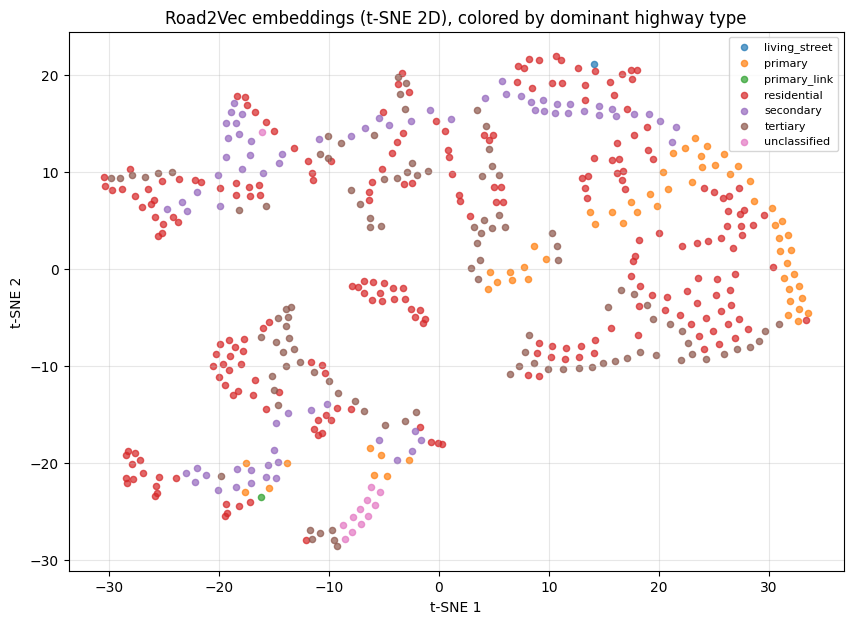

In [16]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
ts = tsne.fit_transform(emb_matrix)

plt.figure(figsize=(10, 7))
for lbl in unique_labels:
    mask = np.array([l == lbl for l in labels])
    plt.scatter(ts[mask, 0], ts[mask, 1],
                s=20, alpha=0.7, label=lbl, color=colors[lbl])
plt.title("Road2Vec embeddings (t-SNE 2D), colored by dominant highway type")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.legend(fontsize=8, loc="best"); plt.grid(alpha=0.3)
plt.show()


### 6.4 Unsupervised clustering on the map

Run k-means in the 64-D embedding space and project the cluster labels back onto the road network. If the embedding has learned functional structure, clusters should look spatially and functionally coherent.


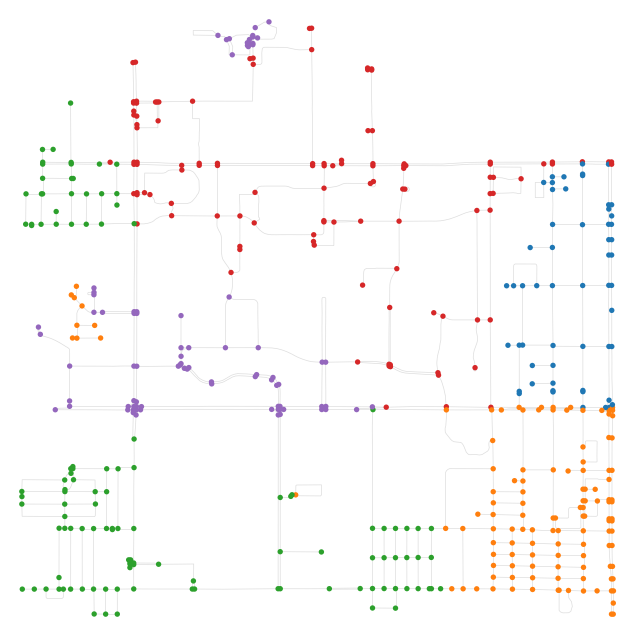

In [17]:
K = 5
km = KMeans(n_clusters=K, n_init=10, random_state=42)
cluster_labels = km.fit_predict(emb_matrix)
node_to_cluster = dict(zip(node_ids, cluster_labels))

cluster_cmap = plt.get_cmap("tab10")
node_colors_c = []
for n in G.nodes():
    c = node_to_cluster.get(n, -1)
    node_colors_c.append(cluster_cmap(c % 10) if c >= 0 else "#cccccc")

fig, ax = ox.plot_graph(
    G,
    node_color=node_colors_c, node_size=15,
    edge_color="#dddddd", edge_linewidth=0.5,
    bgcolor="white",
)


You should see contiguous regions of the network sharing a color. Compare them mentally against your knowledge of Tampa: arterials, residential side streets, and the I-275 / Fowler Avenue interfaces.

> **If you had real GPS trajectory data**, you would replace `walks` with the actual sequences of intersections vehicles passed through. Everything else stays the same.


## 7. Discussion & homework prompts

Pick **two** of the following and write 1–2 paragraphs each. Bring your responses to next class.

1. **From random walks to real trajectories.** What biases does a uniform random walk introduce that real GPS trajectories don't have, and how would those biases distort the learned embedding? (Hint: think about turn proportions on arterials vs residential streets.)

2. **Choosing the embedding dimension.** We used 64. Re-train with `EMB_DIM = 8` and `EMB_DIM = 256`. How does cluster structure change? Connect this to the bias/variance trade-off you'd see in any traffic safety regression.

3. **Window size and "what counts as context".** The `window` parameter sets how many neighboring nodes count as context. Argue, in transportation terms, what window size you'd choose for (a) modeling lane-level driver behavior, (b) modeling regional travel demand, and (c) modeling crash propagation along a corridor.

4. **A downstream task.** Sketch how you would use these embeddings as features for predicting **link travel time** or **crash frequency**. What would you concatenate with them, and what would your loss function be?

5. **Embedding analogies in transportation.** Try to find a vector analogy that holds in your trained model — something like *node_A − node_B + node_C ≈ ?*. Report a successful and a failed analogy. What does each tell you about what the embedding has captured?

6. **Compare to traditional functional classification.** What is *gained* by using a learned embedding instead of a fixed FHWA functional class label? What is *lost*? When would you use which?

### Optional extension (graduate-level)

Re-implement the random walk as a **biased walk** in the spirit of node2vec: add two parameters $p$ and $q$ that control whether the walk prefers to stay local (BFS-like) or wander far (DFS-like). Show how the resulting embedding changes. Connect the BFS/DFS distinction to **structural equivalence** (similar role in the network) vs **homophily** (close in the network), and argue which one matters more for traffic operations.

---

### A note on what road2vec is *not*

It is not a replacement for traffic flow theory — it does not know about conservation, hydrodynamics, or capacity. It is a **representation learning** tool: it gives you a numerical signature of each intersection that downstream models (travel time, crash risk, demand) can consume. The mechanistic models you already know stay valid; the embedding is an additional feature, not a substitute.
